# Descrizione dell'esperimento
L'esperimento si divide in due fasi:
1. Addestramento e validazione in modalità **transductive** su grafi di AD e PD connessi, esattamente come in *test_topology_significance_connected.ipynb*. Vengono misurate le performance a livello di distribuzione
2. Validazione del modello $G_0$, addestrato quindi su grafo non rewired, su un dataset mai visto, prima lasciato invariato e poi alterato con rewiring
### Focus punto 2
##### Razionale
L'idea di fondo è quella di testare se il modello addestrato transduttivamente ha imparato a sfruttare delle feature topologiche particolari. Testandolo sui grafi rewired si testa la sua capacità di generalizzare in assenza di particolari feature che sono state alterate durante il processo di perturbazione.

Questo tipo di esperimento vede i rewiring come dei "generatori di dataset sintetici", interpretazione senza la quale si potrebbe pensare che stia introducendo un bias strutturale, in quanto i rewiring usano i label per perturbare in modo controllato i grafi. 
##### Experimental setting
Vista la randomicità del processo di rewiring, bisogna campionare $N$ grafi perturbati per ogni distribuzione generata. Collezionando le performance per ognuno di questi grafi, si farà una comparazione statistica rispetto ai risultati del punto 1.
##### Criteri di successo
1. La distribuzione è identica: molto improbabile, ma dimostrerebbe definitivamente che il modello ha imparato a sfruttare le feature e che l'ablazione su dataset ha un effetto predicibile
2. La distribuzione è "proporzionata": si intende che ordinando le performance di GCN_plain, R1, R2, R3 e MLP si abbia lo stesso ordine del punto 1. Anche questo sarebbe un ottimo risultato, nonostante le performance scendano.

# Parte 1 - Transductive training

In [10]:
%load_ext autoreload
%autoreload 2

from data_pipeline import *
import torch_geometric.transforms as T

from training_tools.splitter import StratifiedSplitterWithTestHoldout, HoldoutMode
from training_tools.task import TaskBinaryNodeClassification
from training_tools.trainer import Trainer
from training_tools.validation import CrossValidator
from training_tools.evaluation import Evaluator

from models import GCN, GCN_Sage, MLP

from tqdm import tqdm


pre_transform = T.Compose([
    MarkCommonNodes(edge_types=('AD','PD')),
    ReindexConsecutive(),
    MergeRelationsToHomogeneous(merge=['AD','PD'], edge_attr_reduce='sum'),
    FilterSmallConnectedComponents(topk=1)
])

ds = NeuroDegAnc2VecDataset(root='data', pre_transform=pre_transform, force_reload=True)
data = ds[0]

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Processing...
Done!


In [11]:
def compare_models_over_repeats(
    data,                   # Data
    model_factories,           # [factory_A, factory_B, ...]
    splitter_ctor,             # lambda seed, mode: StratifiedNestedSplitter(...)
    task, trainer, mode="transductive",
    n = 10
):
    seeds=list(range(n, 2*n))
    # metriche per modello: dict[name] -> list of per-run test F1
    results = {i: [] for i in range(len(model_factories))}
    artifacts_list = []

    with tqdm(total=len(seeds), desc="Training Progress", unit="iteration") as pbar:
        for seed in seeds:
            splitter = splitter_ctor(seed, mode)
            parts = splitter.split(data, holdout_mode=HoldoutMode.RANDOM, aux_construction_property='is_common', aux_in_test=False)

            for idx, factory in enumerate(model_factories):
                cv = CrossValidator(trainer=trainer, model_factory=factory, mode=mode, select_by="f1")
                artifacts, summary = cv.run(task, data, parts)

                evaluator = Evaluator(model_factory=factory, mode=mode)
                test_metrics = evaluator.evaluate(task, data, parts, artifacts["best_state"])
                results[idx].append(test_metrics["f1"])  # metrica primaria
                artifacts_list.append(artifacts)
            pbar.update(1)

    return results, artifacts_list

def find_absolute_best_state(artifacts, metric_key="best_val_f1"):
    best_overall_metric = -1
    best_overall_state = None
    best_run_idx = -1
    best_fold_idx = -1
    
    # Iteriamo su ogni run (ogni dizionario nella lista)
    for run_idx, run in enumerate(artifacts):
        target_fold = run.get('best_fold')
        per_fold_list = run.get('per_fold', [])
        
        # Cerchiamo i dati della fold che ha performato meglio in questa specifica run
        fold_data = next((f for f in per_fold_list if f.get('fold') == target_fold), None)
        
        if fold_data:
            # Estraiamo il valore della metrica (es. best_val_f1)
            current_metric = fold_data.get('history', {}).get(metric_key, 0)
            
            # Se è migliore di quello che abbiamo visto finora, aggiorniamo il "best"
            if current_metric > best_overall_metric:
                best_overall_metric = current_metric
                best_overall_state = run.get('best_state')
                best_run_idx = run_idx
                best_fold_idx = target_fold

    print(f"🏆 Miglior Run trovata all'indice: {best_run_idx}")
    print(f"🎯 Miglior Fold della run: {best_fold_idx}")
    print(f"📈 Valore di {metric_key}: {best_overall_metric:.4f}")
    
    return best_overall_state

### Actual training

In [12]:
from graph_data_manipulation import rewire_degree_preserving_complete, rewire_degree_preserving_stratified_connected, rewire_non_degree_preserving_stratified_complete
import pickle


mode = 'transductive'
seed = 42
gcn_factory = lambda : GCN(in_channels=data.x.size(1), hidden_channels=64, out_channels=1, dropout=0)
mlp_factory = lambda : MLP(in_channels=data.x.size(1), hidden_channels=64, out_channels=1, dropout=0)
splitter_ctor = lambda seed, mode: StratifiedSplitterWithTestHoldout(test_size=0.1, n_splits=5, seed=seed, mode=mode)


task    = TaskBinaryNodeClassification(threshold=0.5, pos_weight=None)
trainer = Trainer(lr=1e-3, weight_decay=5e-4, max_epochs=50, patience=10)

n = 10  # Numero di training
m = 20  # Numero di rewiring

rewiring_algs = {
    "R1": rewire_degree_preserving_complete,
    "R2": rewire_degree_preserving_stratified_connected,
    "R3": rewire_non_degree_preserving_stratified_complete
}

for name, alg in rewiring_algs.items():
    print(f"{name} | {alg.__name__}")

training_metrics = dict() # key: `model's name`; value: List[artifact]

train = True
overwrite = False
from pathlib import Path
saved_pkl = './training_output/best_state_gcn_AD-PD_transductive.pkl'
if Path(saved_pkl).exists() and not overwrite:
    artifacts = dict()
    with open(saved_pkl, "rb") as f:
        artifacts['best_state'] = pickle.load(f)

    train = False

if train:
    # --- Training MLP
    test_metrics_mlp, artifacts_mlp = compare_models_over_repeats(
        data, 
        [mlp_factory], 
        splitter_ctor, task, trainer, mode='transductive', n=n)

    training_metrics['MLP'] = test_metrics_mlp[0]

    # --- Training GCN
    test_metrics_gcn = []
    gcn_artifacts = list()
    for x in tqdm(range(n*m), desc="GCN training", unit="trainings"): 
        splitter = StratifiedSplitterWithTestHoldout(test_size=0.1, n_splits=5, seed=seed + x, mode=mode)
        parts = splitter.split(data, holdout_mode=HoldoutMode.RANDOM, aux_construction_property='is_common', aux_in_test=False)

        cv = CrossValidator(trainer=trainer, model_factory=gcn_factory, mode=mode, select_by="f1")
        artifacts, summary = cv.run(task, data, parts)

        gcn_artifacts.append(artifacts)

        evaluator = Evaluator(model_factory=gcn_factory, mode=mode)
        test_metrics_gcn.append(evaluator.evaluate(task, data, parts, artifacts["best_state"])['f1'])

    training_metrics['GCN'] = test_metrics_gcn

    # --- Training GCN on rewiring
    progress_bar = tqdm(total=n*m*len(rewiring_algs), unit="trainings")
    test_metrics_rew = dict()
    for alg_name in rewiring_algs.keys():
        test_metrics_rew[alg_name] = list()

    rew_count = 0
    for alg_name, rew_alg in rewiring_algs.items():
        rew_count += 1
        rew_artifacts_list = list()
        for i in range(m):
            progress_bar.set_description(f"[{rew_count}] [{alg_name}] Training on {i+1}th rewiring")
            g_rewired = rew_alg(
                data,
                seed=seed + i
            )

            #for x in tqdm.tqdm(range(n), desc="Training GCN on original and rewired graphs", unit="trainings"):
            for j in range(n):
                splitter = StratifiedSplitterWithTestHoldout(test_size=0.1, n_splits=5, seed=seed + j, mode=mode)
                rewired_parts = splitter.split(g_rewired, holdout_mode=HoldoutMode.RANDOM, aux_construction_property='is_common', aux_in_test=False)

                cv_rew = CrossValidator(trainer=trainer, model_factory=gcn_factory, mode=mode, select_by="f1")
                artifacts_rew, summary_rew = cv_rew.run(task, g_rewired, rewired_parts)

                rew_artifacts_list.append(artifacts_rew)

                evaluator = Evaluator(model_factory=gcn_factory, mode=mode)
                test_metrics_rew[alg_name].append(evaluator.evaluate(task, g_rewired, rewired_parts, artifacts_rew["best_state"])['f1'])

                progress_bar.update(1)
            
            progress_bar.update(1)

    training_metrics = {**training_metrics, **test_metrics_rew}

    output_label = 'AD-PD_transductive'
    training_output_folder = './training_output'
    Path(training_output_folder).mkdir(exist_ok=True)

    import json
    with open(f'{training_output_folder}/scores_gcn_{output_label}.json', 'w', encoding='utf-8') as f:
        json.dump(training_metrics, f, indent=4)

    with open(f'{training_output_folder}/best_state_gcn_{output_label}.pkl', 'wb') as f:
        pickle.dump(find_absolute_best_state(gcn_artifacts), f)

    with open(f'{training_output_folder}/best_state_mlp_{output_label}.pkl', 'wb') as f:
        pickle.dump(artifacts_mlp[0]['best_state'], f)
    

R1 | rewire_degree_preserving_complete
R2 | rewire_degree_preserving_stratified_connected
R3 | rewire_non_degree_preserving_stratified_complete


### Function definition for experiment and plotting

In [13]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_recall_fscore_support,
)
from tqdm import tqdm

# Import delle strategie di rewiring dal modulo dedicato
from graph_data_manipulation.rewiring import (
    rewire_degree_preserving_complete,  # R1
    rewire_degree_preserving_stratified_connected,  # R2
    rewire_non_degree_preserving_stratified_complete,  # R3
)
from training_tools.evaluation.Evaluator import Evaluator


# ==========================================
# For experiment
# ==========================================

def evaluate(task, data, mask, state_dict, is_mlp=False):
    """Esegue l'inferenza e calcola le metriche e la matrice di confusione."""
    model = gcn_factory() if not is_mlp else mlp_factory()
    model.load_state_dict(state_dict)
    model.eval()

    parts = {
        "supervised_mask": torch.as_tensor(
            mask, dtype=torch.bool, device=data.y.device
        ),
        "test_mask": torch.as_tensor(
            mask, dtype=torch.bool, device=data.y.device
        ),
    }

    y_true, y_pred = task.predict(
        model, data, parts, phase="test", fold_k=None, mode="transductive"
    )

    yt = y_true.view(-1).cpu().numpy()
    yp = y_pred.view(-1).cpu().numpy()

    acc = accuracy_score(yt, yp)
    prec, rec, f1, _ = precision_recall_fscore_support(
        yt, yp, average="binary", zero_division=0
    )
    cm = confusion_matrix(yt, yp, labels=[0, 1])

    return {
        "metrics": {
            "accuracy": float(acc),
            "precision": float(prec),
            "recall": float(rec),
            "f1": float(f1),
        },
        "confusion_matrix": cm,
    }

# ==========================================
# For plotting performances
# ==========================================

def plot_performance_boxplots(df_boxplot, res_original, res_mlp, title):
    """Genera i boxplot delle metriche sui null models confrontandoli con il grafo originale."""
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(12, 6))

    ax = sns.boxplot(
        x="Metrica",
        y="Valore",
        hue="Strategia",
        data=df_boxplot,
        palette="Set2",
    )

    # Aggiunta delle linee orizzontali del grafo Originale (T) per confronto
    metrics_keys = ["accuracy", "precision", "recall", "f1"]
    for i, metric in enumerate(metrics_keys):
        orig_val = res_original["metrics"][metric]
        mlp_val = res_mlp["metrics"][metric]
        ax.hlines(
            orig_val,
            xmin=i - 0.4,
            xmax=i + 0.4,
            colors="red",
            linestyles="--",
            alpha=0.8,
            label="Originale (T)" if i == 0 else "",
        )
        ax.hlines(
            mlp_val,
            xmin=i - 0.4,
            xmax=i + 0.4,
            colors="blue",
            linestyles="--",
            alpha=0.8,
            label="MLP" if i == 0 else "",
        )

    plt.title(
        title
    )
    plt.ylim(0, 1.05)
    plt.legend(loc="lower left")
    plt.tight_layout()
    plt.show()


def plot_confusion_matrices(cm_original, cm_data, title):
    """Genera i subplot delle confusion matrix normalizzate per riga (Recall per classe)."""
    sns.set_theme(style="white")
    fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))

    # 1. Plot Grafo Originale
    sns.heatmap(
        cm_original / cm_original.sum(axis=1)[:, None],
        annot=True,
        fmt=".2%",
        cmap="Blues",
        ax=axes[0],
        cbar=False,
        xticklabels=["Pred 0", "Pred 1"],
        yticklabels=["True 0", "True 1"],
    )
    axes[0].set_title("Originale (T)")

    # 2. Plot Strategie Mediate
    for idx, (label, cm_list) in enumerate(cm_data.items(), start=1):
        mean_cm = np.mean(cm_list, axis=0)
        mean_cm_norm = mean_cm / mean_cm.sum(axis=1)[:, None]

        # Creazione dei label personalizzati (Percentuale + Conteggio Medio)
        labels = np.array(
            [
                [
                    "{:.2%}\n(avg: {:.1f})".format(val, count)
                    for val, count in zip(row_norm, row_raw)
                ]
                for row_norm, row_raw in zip(mean_cm_norm, mean_cm)
            ]
        )

        sns.heatmap(
            mean_cm_norm,
            annot=labels,
            fmt="",
            cmap="Blues",
            ax=axes[idx],
            cbar=False,
            xticklabels=["Pred 0", "Pred 1"],
            yticklabels=["True 0", "True 1"],
        )
        axes[idx].set_title(f"Media {label}")

    plt.suptitle(
        title,
        fontsize=16,
        y=1.05,
    )
    plt.tight_layout()
    plt.show()


# ==========================================
# For plotting graphs
# ==========================================

import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch_geometric.data import HeteroData

def plot_graph_comparison(test_ds: HeteroData, rewiring_strategies: dict, max_nodes_to_plot: int = 200, seed: int = 42):
    """
    Genera 4 subplot affiancati mostrando l'impatto visivo del rewiring sulla topologia del grafo.
    Campione un sottografo se il dataset è troppo grande, preservando la coerenza visiva.
    """
    # 1. Funzione helper per convertire HeteroData in un grafo NetworkX semplice (omogeneo)
    def to_nx_graph(hetero_data):
        G = nx.Graph()
        
        # Aggiungi nodi con la loro etichetta (classi 0, 1, 2)
        labels = hetero_data.y.cpu().numpy()
        for idx, l in enumerate(labels):
            G.add_node(idx, label=l)
            
        # Estrai e unisci gli edge index di tutte le relazioni eterogenee
        edge_index = hetero_data.edge_index
        edges = edge_index.t().cpu().numpy()
        G.add_edges_from(edges)
            
        return G

    # Genera i 4 grafi da plottare
    graphs_dict = {"Originale (T)": to_nx_graph(test_ds)}
    for label, rewire_fn in rewiring_strategies.items():
        # Generiamo un grafo sintetico usando il seed di riferimento
        t_synth = rewire_fn(test_ds, seed=seed)
        graphs_dict[label] = to_nx_graph(t_synth)

    # 2. Campionamento (Sottografo) se ci sono troppi nodi per evitare lag grafici
    # Usiamo il grafo originale come riferimento per mappare i nodi stabili da plottare
    ref_G = graphs_dict["Originale (T)"]
    if ref_G.number_of_nodes() > max_nodes_to_plot:
        # Seleziona i nodi con il grado più alto o semplicemente i primi N per consistenza
        nodes_to_keep = sorted(ref_G.nodes(), key=lambda n: ref_G.degree(n), reverse=True)[:max_nodes_to_plot]
    else:
        nodes_to_keep = list(ref_G.nodes())

    # 3. Calcolo del layout fisso (basato sul grafo originale) 
    # Mantenere le stesse posizioni XY permette di vedere l'effettivo "spostamento" degli archi
    pos = nx.spring_layout(ref_G.subgraph(nodes_to_keep), seed=seed)

    # Mappa dei colori basata sulle classi di test_ds.y (0: AD, 1: PD, 2: Overlap)
    color_map_nodes = {0: "#4c72b0", 1: "#dd8452", 2: "#55a868"}

    fig, axes = plt.subplots(1, 4, figsize=(24, 6))
    
    for idx, (title, G) in enumerate(graphs_dict.items()):
        ax = axes[idx]
        sub_G = G.subgraph(nodes_to_keep)
        
        # Estrai i colori dei nodi presenti nel sottografo
        node_colors = [color_map_nodes[sub_G.nodes[n]['label']] for n in sub_G.nodes()]
        
        # Calcolo di metriche veloci da stampare nel titolo del plot
        avg_degree = np.mean([d for _, d in G.degree()])
        num_edges = G.number_of_edges()
        
        # Disegno del grafo
        nx.draw_networkx_nodes(
            sub_G, pos, 
            node_size=25, 
            node_color=node_colors, 
            ax=ax, 
            alpha=0.8
        )
        nx.draw_networkx_edges(
            sub_G, pos, 
            alpha=0.15, 
            edge_color="gray", 
            ax=ax
        )
        
        ax.set_title(f"{title}\nArchi Totali: {num_edges}\nGrado Medio: {avg_degree:.2f}", fontsize=12)
        ax.axis("off")

    # Legenda personalizzata per le classi di proteine
    from matplotlib.lines import Line2D
    legend_elements = [
        plt.Line2D([0], [0], marker='o', color='w', label='Classe 0 (AD)', markerfacecolor='#4c72b0', markersize=10),
        plt.Line2D([0], [0], marker='o', color='w', label='Classe 1 (PD)', markerfacecolor='#dd8452', markersize=10),
        plt.Line2D([0], [0], marker='o', color='w', label='Classe 2 (Both)', markerfacecolor='#55a868', markersize=10)
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=3, fontsize=12, bbox_to_anchor=(0.5, -0.05))
    
    plt.suptitle(f"Visualizzazione Comparativa Topologica (Campionamento di {max_nodes_to_plot} nodi chiave)", fontsize=16, y=1.05)
    plt.tight_layout()
    plt.show()


### Experiment
Given a set of datasets for testing, make a test dataset for each pair and measure inference performances

Processing...


Test ALS HD


Done!


0: 31, 1: 33, 2: 4
Esecuzione 100 round per la strategia T1...


100%|██████████| 100/100 [00:02<00:00, 36.28it/s]


Esecuzione 100 round per la strategia T2...


100%|██████████| 100/100 [00:03<00:00, 32.22it/s]


Esecuzione 100 round per la strategia T3...


100%|██████████| 100/100 [00:01<00:00, 83.53it/s]


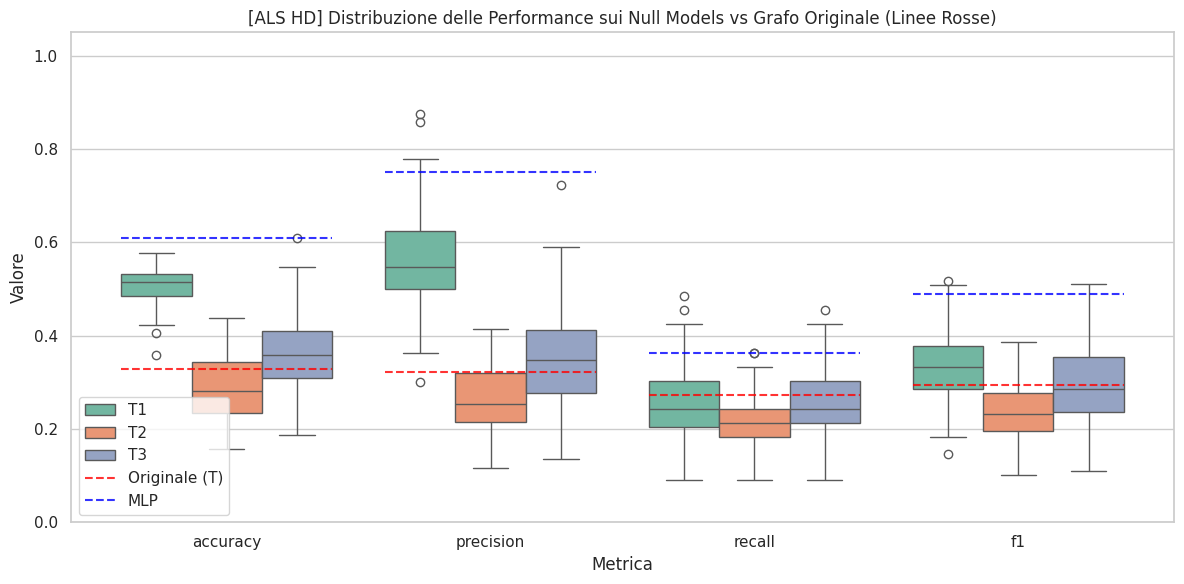

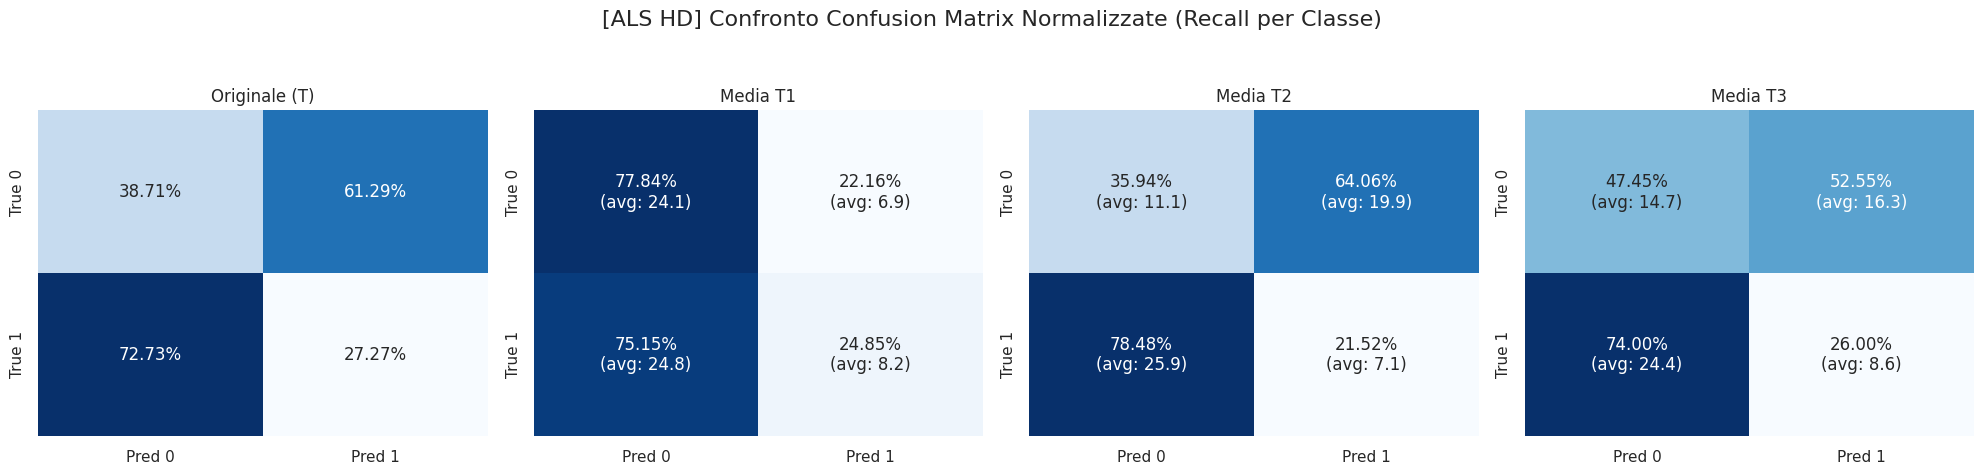

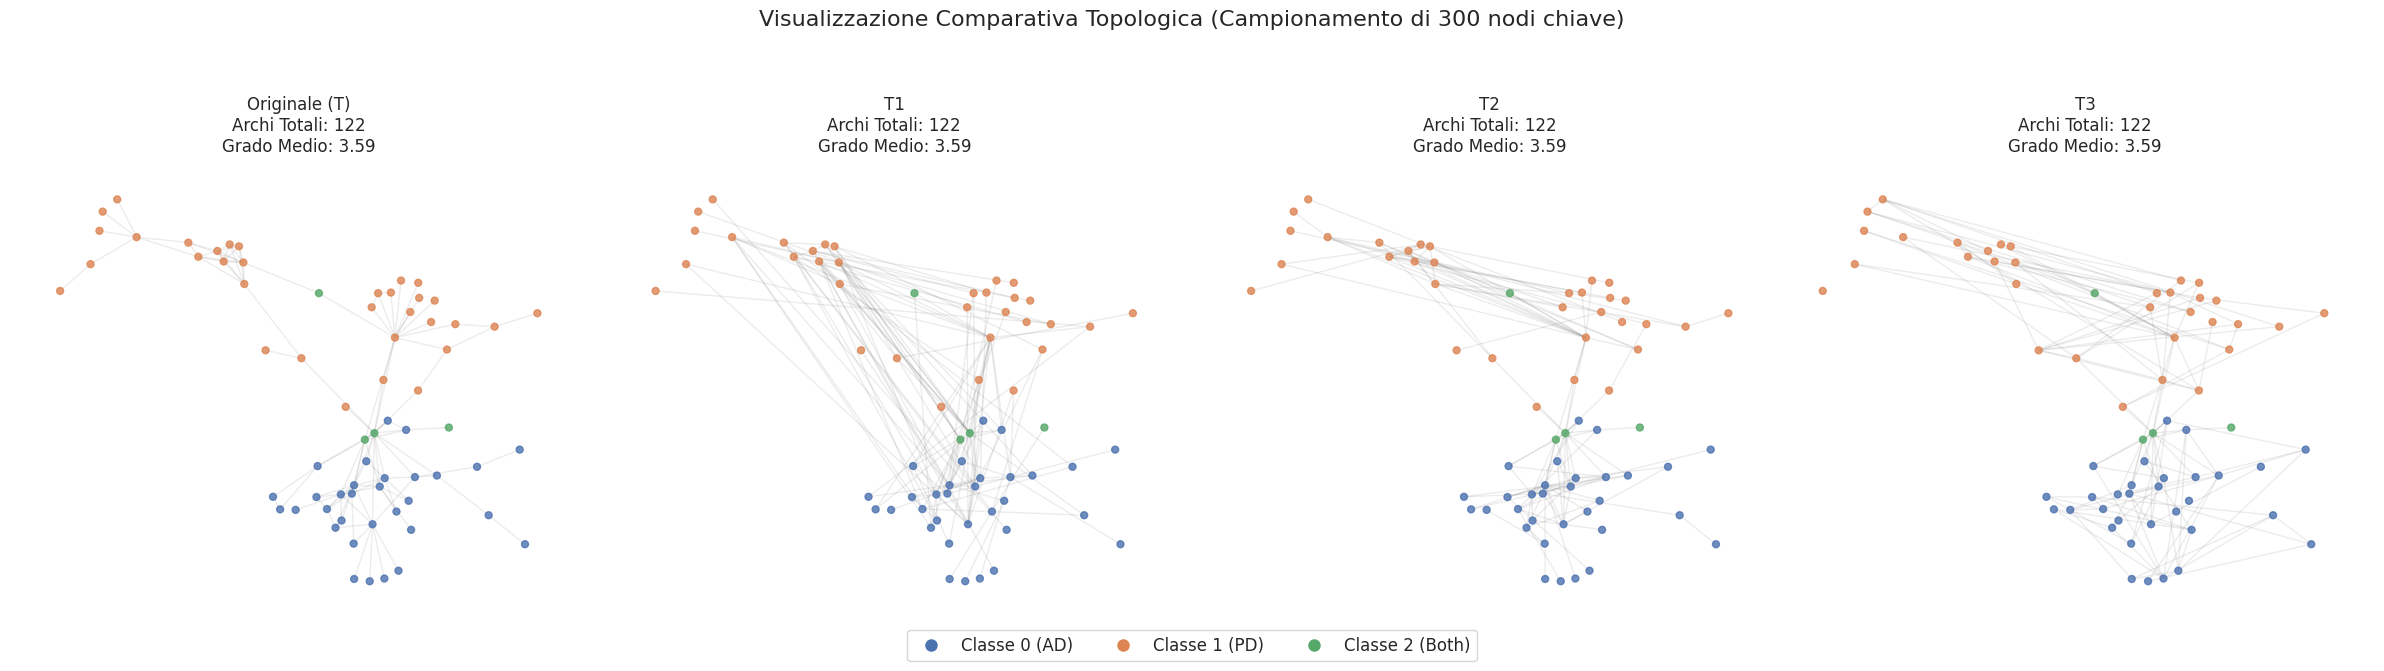

Test ALS MSA


Processing...
Done!


0: 28, 1: 22, 2: 7
Esecuzione 100 round per la strategia T1...


100%|██████████| 100/100 [00:02<00:00, 42.42it/s]


Esecuzione 100 round per la strategia T2...


100%|██████████| 100/100 [00:01<00:00, 57.72it/s]


Esecuzione 100 round per la strategia T3...


100%|██████████| 100/100 [00:00<00:00, 106.68it/s]


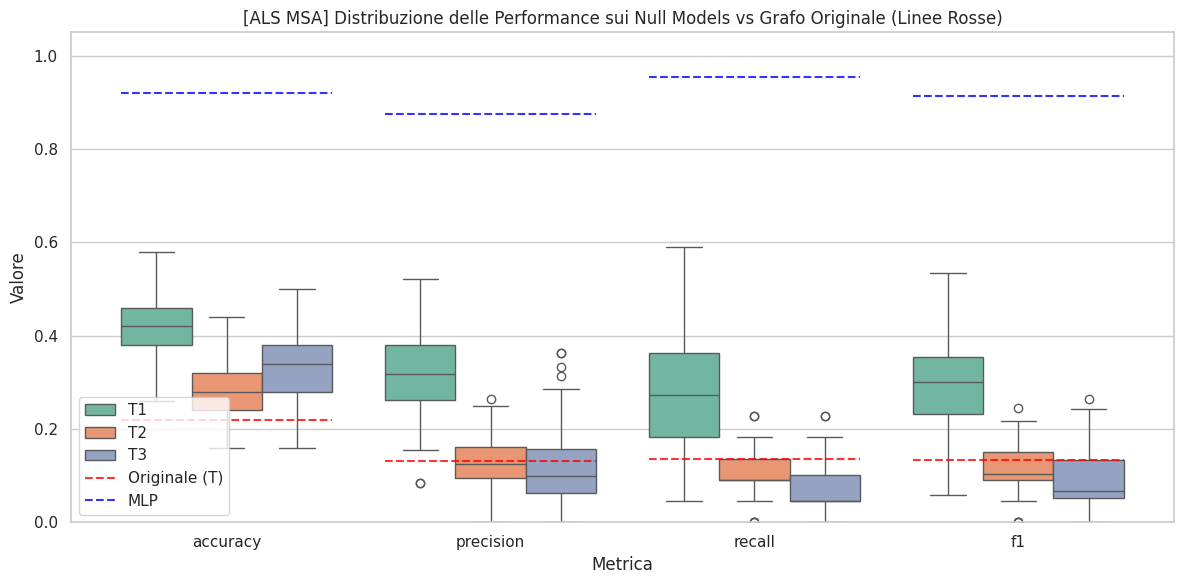

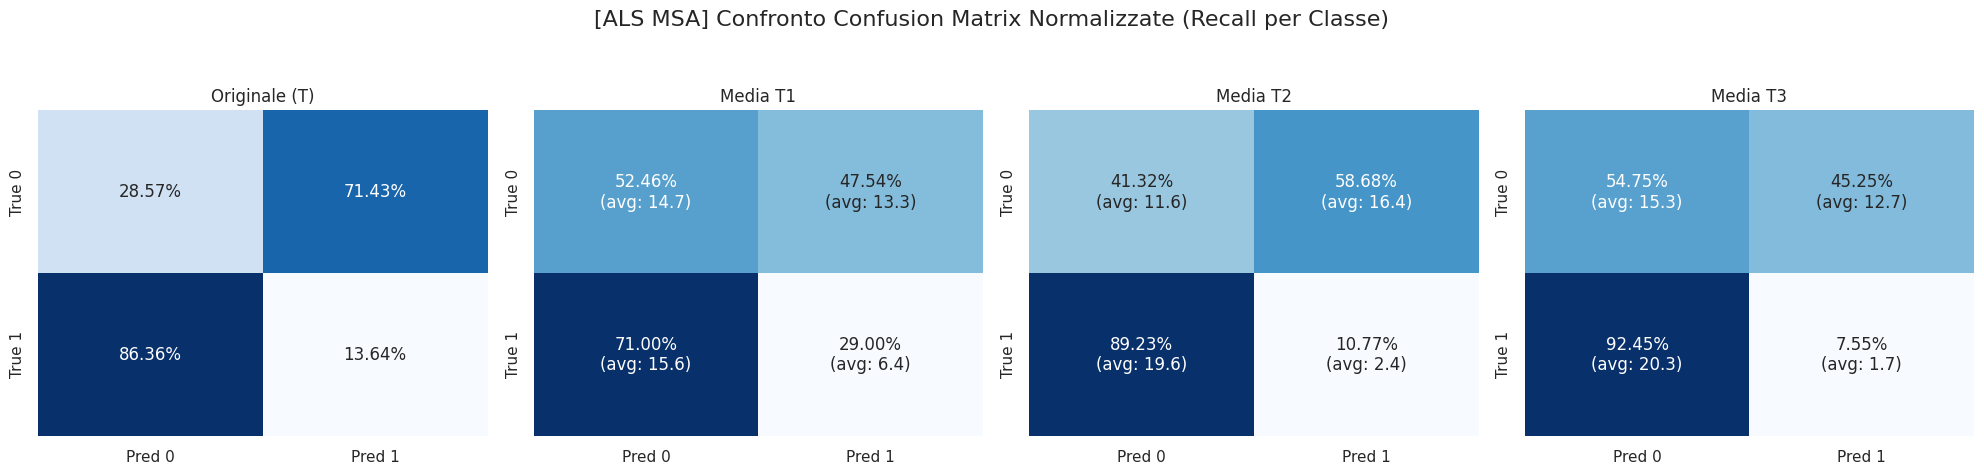

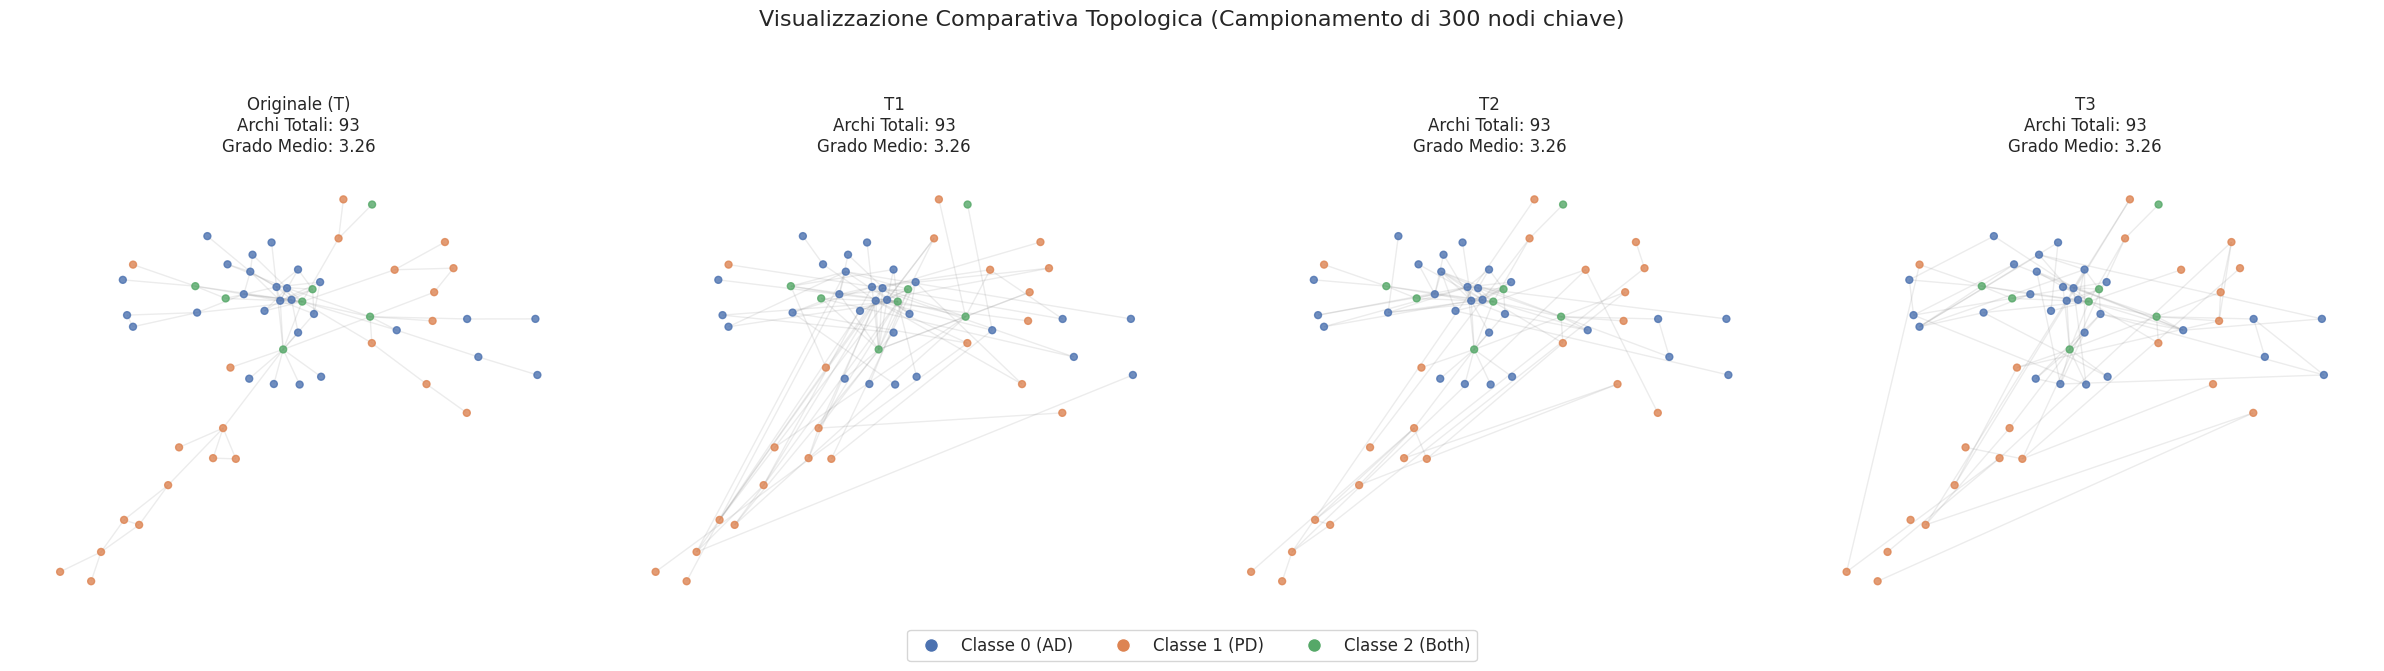

Test HD MSA


Processing...
Done!


0: 34, 1: 28, 2: 2
Esecuzione 100 round per la strategia T1...


100%|██████████| 100/100 [00:02<00:00, 42.66it/s]


Esecuzione 100 round per la strategia T2...


100%|██████████| 100/100 [00:02<00:00, 49.45it/s]


Esecuzione 100 round per la strategia T3...


100%|██████████| 100/100 [00:01<00:00, 90.05it/s]


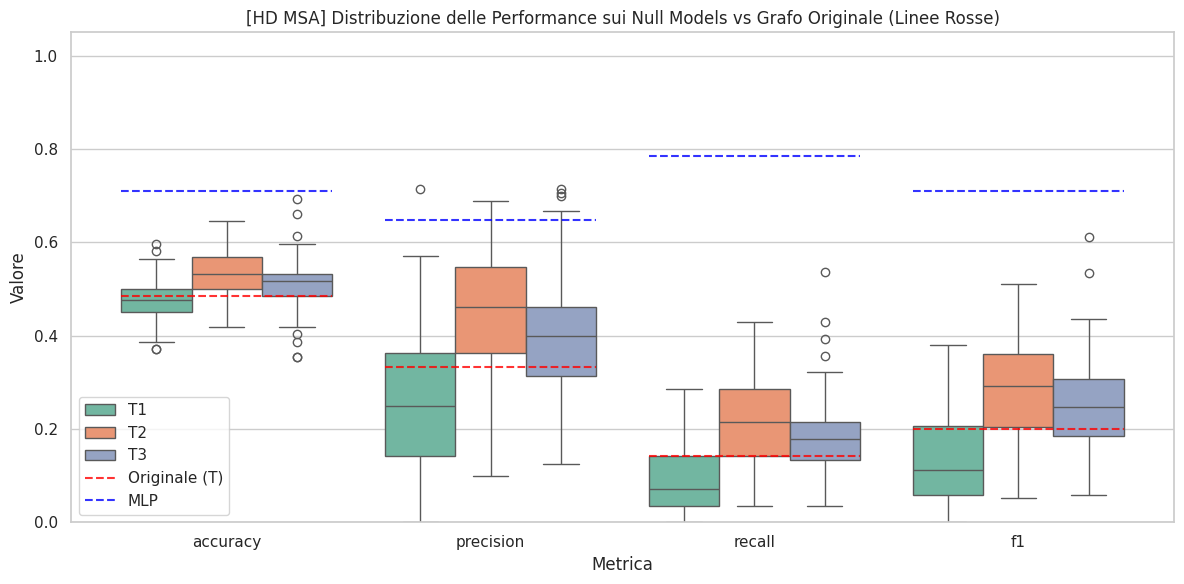

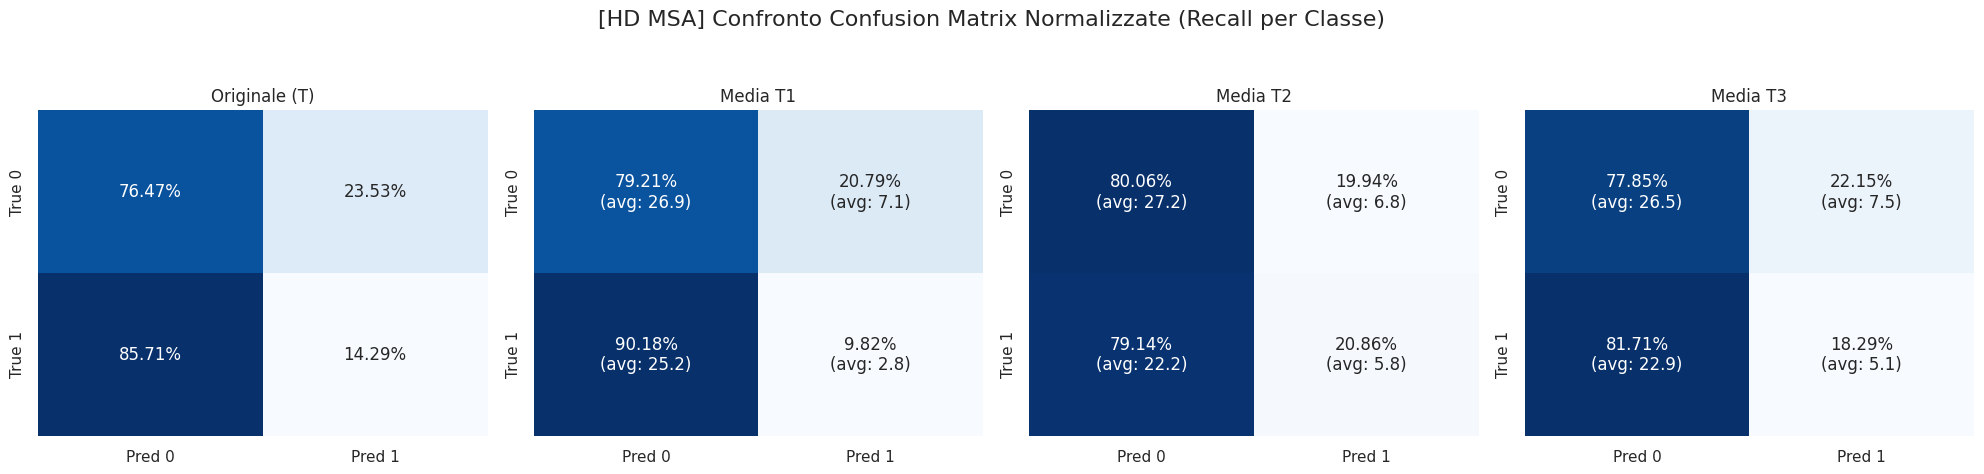

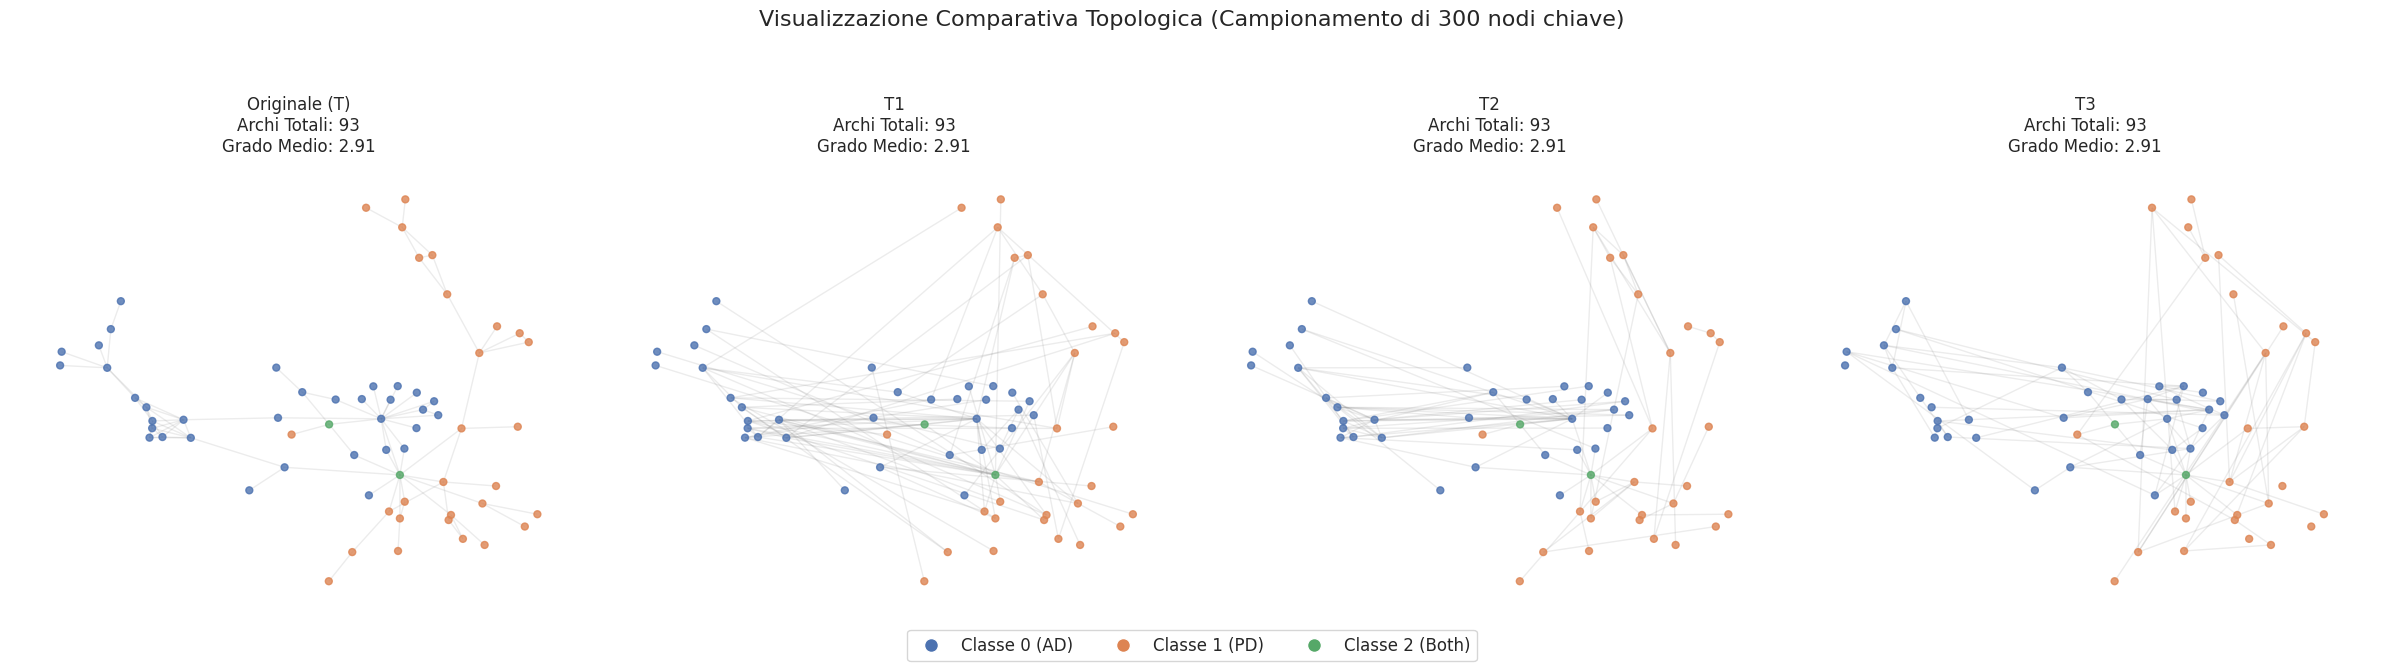

In [14]:
from pathlib import Path
import itertools
import torch
import numpy as np
import pickle

project_root = Path('.')
data_root = project_root / "data"

with open('./training_output/best_state_mlp_ALS-MSA_transductive.pkl', 'rb') as f:
    best_mlp_state = pickle.load(f)

class_labels = (('T1', 'T2'))

test_datasets = ('ALS', 'HD', 'MSA')
for t1, t2 in itertools.combinations(test_datasets, 2):
    print(f"Test {t1} {t2}")
    c0_nodes_csv = project_root / "networks" / f"{t1}_nodes.csv"
    c1_nodes_csv = project_root / "networks" / f"{t2}_nodes.csv"
    c0_edges_csv = project_root / "networks" / f"{t1}_edges.csv"
    c1_edges_csv = project_root / "networks" / f"{t2}_edges.csv"

    pre_transform = T.Compose([
        MarkCommonNodes(edge_types=class_labels),
        ReindexConsecutive(),
        MergeRelationsToHomogeneous(merge=class_labels, edge_attr_reduce='sum'),
        FilterSmallConnectedComponents(topk=1),
        # FilterLargestComponentPerClass(class_labels=(0, 1))
    ])

    test_ds = NeuroDegAnc2VecDataset(
        root=str(data_root), # Directory where processed data (hetero.pt) will be stored
        c0_nodes_csv=str(c0_nodes_csv),
        c1_nodes_csv=str(c1_nodes_csv),
        c0_edges_csv=str(c0_edges_csv),
        c1_edges_csv=str(c1_edges_csv),
        force_reload=True, # Set to True to re-process if needed, False to load from cache
        class_labels=class_labels,
        transform=None,
        pre_transform=pre_transform
    )[0]


    NUM_ROUNDS = 100
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    evaluator = Evaluator(model_factory=gcn_factory, mode="transductive")

    num_nodes_T = test_ds.y.size(0)
    full_mask = torch.ones(
        num_nodes_T, dtype=torch.bool, device=test_ds.y.device
    ) & ~(test_ds.y == 2)
    full_test_mask = (test_ds.y == 0) | (test_ds.y == 1)

    rewiring_strategies = {
        "T1": rewire_degree_preserving_complete,
        "T2": rewire_degree_preserving_stratified_connected,
        "T3": rewire_non_degree_preserving_stratified_complete,
    }
    
    bincounts = np.bincount(test_ds.y)
    print(f"0: {bincounts[0]}, 1: {bincounts[1]}, 2: {bincounts[2]}")

    # Strutture dati per la collezione dei risultati
    boxplot_data = []
    cm_data = {label: [] for label in rewiring_strategies.keys()}

    # --- 1. VALUTAZIONE GRAFO ORIGINALE ---
    res_original = evaluate(
        task, test_ds, full_mask, artifacts["best_state"]
    )

    mlp_res = evaluate(
        task, test_ds, full_mask, best_mlp_state, is_mlp=True
    )
    cm_original = res_original["confusion_matrix"]

    # --- 2. CICLO DI RUN SUI NULL MODELS ---
    for label, rewire_fn in rewiring_strategies.items():
        print(f"Esecuzione {NUM_ROUNDS} round per la strategia {label}...")

        for r in tqdm(range(NUM_ROUNDS)):
            T_synth = rewire_fn(test_ds, seed=r)
            res = evaluate(
                task, T_synth, full_test_mask, artifacts["best_state"]
            )

            # Accumulo dati per il boxplot
            for metric_name, val in res["metrics"].items():
                boxplot_data.append(
                    {
                        "Strategia": label,
                        "Metrica": metric_name,
                        "Valore": val,
                    }
                )

            # Accumulo matrici di confusione
            cm_data[label].append(res["confusion_matrix"])

    # Conversione dei dati del boxplot in DataFrame Pandas
    df_box = pd.DataFrame(boxplot_data)

    # --- 3. VISUALIZZAZIONE GRAFICI ---
    plot_performance_boxplots(df_box, res_original, mlp_res, f"[{t1} {t2}] Distribuzione delle Performance sui Null Models vs Grafo Originale (Linee Rosse)")
    plot_confusion_matrices(cm_original, cm_data, f"[{t1} {t2}] Confronto Confusion Matrix Normalizzate (Recall per Classe)")
    plot_graph_comparison(test_ds, rewiring_strategies, max_nodes_to_plot=300, seed=42)